# Formula 1 Data Science Project
## SVM (Support Vector Machines) Module

This notebook covers:
- **Overview images**: Hyperplane/margin diagram and kernel trick diagram
- **Data Prep**: Loading, cleaning, scaling, and splitting F1 lap data
- **SVM Classification**: Linear, Polynomial, and RBF kernels with cost tuning
- **Results**: Confusion matrices, decision boundary visualizations, accuracy comparison
- **Conclusions**: What SVM tells us about F1 tyre compound prediction

---
## Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, classification_report
)

import os
os.makedirs('img', exist_ok=True)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Generate Overview Diagrams

These two diagrams are used in the SVM Overview section of the website.

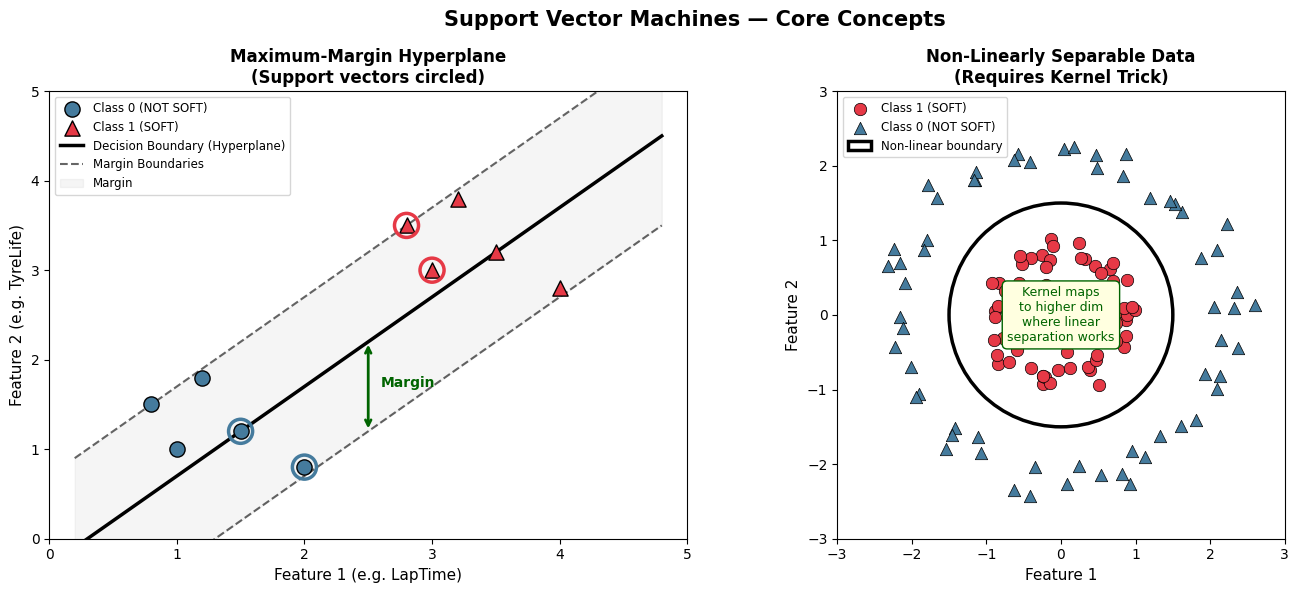

Saved → img/svm_overview1.png


In [2]:
# ── Overview Image 1: Maximum-Margin Hyperplane ─────────────────────────────
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Support Vector Machines — Core Concepts', fontsize=15, fontweight='bold')

# Left: linearly separable classes with margin
ax = axes[0]
cls0 = np.array([[1,1],[1.5,1.2],[2,0.8],[1.2,1.8],[0.8,1.5]])
cls1 = np.array([[3,3],[3.5,3.2],[4,2.8],[3.2,3.8],[2.8,3.5]])

ax.scatter(cls0[:,0], cls0[:,1], s=120, c='#457b9d', edgecolors='k', zorder=5, label='Class 0 (NOT SOFT)')
ax.scatter(cls1[:,0], cls1[:,1], s=120, c='#e63946', edgecolors='k', marker='^', zorder=5, label='Class 1 (SOFT)')

# Decision boundary: x2 = x1 - 0.3 (slope=1, intercept=-0.3)
x_line = np.linspace(0.2, 4.8, 100)
ax.plot(x_line, x_line - 0.3, 'k-', lw=2.5, label='Decision Boundary (Hyperplane)')
ax.plot(x_line, x_line - 1.3, 'k--', lw=1.5, alpha=0.6, label='Margin Boundaries')
ax.plot(x_line, x_line + 0.7, 'k--', lw=1.5, alpha=0.6)

# Fill margin
ax.fill_between(x_line, x_line - 1.3, x_line + 0.7, alpha=0.08, color='gray', label='Margin')

# Support vectors (circled)
sv0 = np.array([[1.5,1.2],[2,0.8]])
sv1 = np.array([[2.8,3.5],[3,3]])
ax.scatter(sv0[:,0], sv0[:,1], s=300, facecolors='none', edgecolors='#457b9d', lw=2.5, zorder=6)
ax.scatter(sv1[:,0], sv1[:,1], s=300, facecolors='none', edgecolors='#e63946', lw=2.5, zorder=6)

# Margin width annotation
ax.annotate('', xy=(2.5, 2.2), xytext=(2.5, 1.2),
            arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=2))
ax.text(2.6, 1.7, 'Margin', color='darkgreen', fontweight='bold', fontsize=10)

ax.set_xlim(0, 5); ax.set_ylim(0, 5)
ax.set_xlabel('Feature 1 (e.g. LapTime)', fontsize=11)
ax.set_ylabel('Feature 2 (e.g. TyreLife)', fontsize=11)
ax.set_title('Maximum-Margin Hyperplane\n(Support vectors circled)', fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left')

# Right: non-linearly separable → kernel maps to higher dim
ax2 = axes[1]
theta = np.linspace(0, 2*np.pi, 60)
inner_x = 0.8 * np.cos(theta) + np.random.randn(60)*0.15
inner_y = 0.8 * np.sin(theta) + np.random.randn(60)*0.15
outer_x = 2.2 * np.cos(theta) + np.random.randn(60)*0.15
outer_y = 2.2 * np.sin(theta) + np.random.randn(60)*0.15

ax2.scatter(inner_x, inner_y, s=80, c='#e63946', edgecolors='k', lw=0.5, label='Class 1 (SOFT)')
ax2.scatter(outer_x, outer_y, s=80, c='#457b9d', edgecolors='k', lw=0.5, marker='^', label='Class 0 (NOT SOFT)')

# Draw non-linear boundary
circle = plt.Circle((0,0), 1.5, fill=False, color='black', lw=2.5, label='Non-linear boundary')
ax2.add_patch(circle)
ax2.set_xlim(-3, 3); ax2.set_ylim(-3, 3)
ax2.set_aspect('equal')
ax2.set_xlabel('Feature 1', fontsize=11)
ax2.set_ylabel('Feature 2', fontsize=11)
ax2.set_title('Non-Linearly Separable Data\n(Requires Kernel Trick)', fontweight='bold')
ax2.legend(fontsize=8.5)

ax2.text(0, 0, 'Kernel maps\nto higher dim\nwhere linear\nseparation works',
         ha='center', va='center', fontsize=9, color='darkgreen',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='darkgreen'))

plt.tight_layout()
plt.savefig('img/svm_overview1.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_overview1.png')

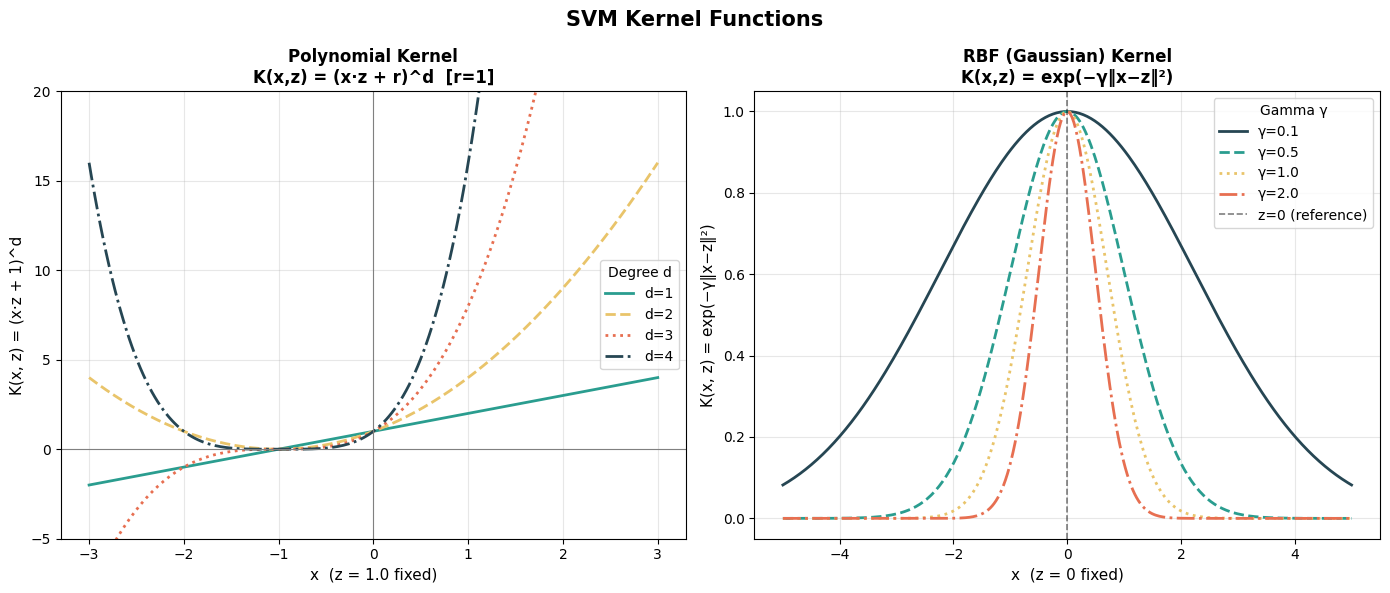

Saved → img/svm_overview2.png


In [3]:
# ── Overview Image 2: Kernel Functions + Polynomial Example ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('SVM Kernel Functions', fontsize=15, fontweight='bold')

# Left panel: Polynomial kernel K(x,z) = (x·z + r)^d  for 1D illustration
ax = axes[0]
x_vals = np.linspace(-3, 3, 200)
z_fixed = 1.0  # fixed reference point
for d, color, ls in [(1, '#2a9d8f', '-'), (2, '#e9c46a', '--'), (3, '#e76f51', ':'), (4, '#264653', '-.')] :
    k_vals = (x_vals * z_fixed + 1)**d
    ax.plot(x_vals, k_vals, color=color, lw=2, linestyle=ls, label=f'd={d}')
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8)
ax.set_ylim(-5, 20)
ax.set_xlabel('x  (z = 1.0 fixed)', fontsize=11)
ax.set_ylabel('K(x, z) = (x·z + 1)^d', fontsize=11)
ax.set_title('Polynomial Kernel\nK(x,z) = (x·z + r)^d  [r=1]', fontweight='bold')
ax.legend(title='Degree d', fontsize=10)
ax.grid(alpha=0.3)

# Right panel: RBF kernel K(x,z) = exp(-γ||x-z||²)
ax2 = axes[1]
x_center = 0
x_range = np.linspace(-5, 5, 300)
for gamma, color, ls in [(0.1,'#264653','-'), (0.5,'#2a9d8f','--'), (1.0,'#e9c46a',':'), (2.0,'#e76f51','-.')]:
    rbf = np.exp(-gamma * (x_range - x_center)**2)
    ax2.plot(x_range, rbf, color=color, lw=2, linestyle=ls, label=f'γ={gamma}')
ax2.axvline(x_center, color='black', lw=1.2, linestyle='--', alpha=0.5, label=f'z={x_center} (reference)')
ax2.set_xlabel('x  (z = 0 fixed)', fontsize=11)
ax2.set_ylabel('K(x, z) = exp(−γ‖x−z‖²)', fontsize=11)
ax2.set_title('RBF (Gaussian) Kernel\nK(x,z) = exp(−γ‖x−z‖²)', fontweight='bold')
ax2.legend(title='Gamma γ', fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('img/svm_overview2.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_overview2.png')

In [4]:
# ── Polynomial Kernel Worked Example: 2D → 6D ───────────────────────────────
# Polynomial kernel with r=1, d=2:  K(x,z) = (x·z + 1)²
# The implicit feature map φ(x) for 2D input x=(x1,x2):
#   φ(x) = (1, √2·x1, √2·x2, x1², √2·x1·x2, x2²)  →  6 dimensions

def poly_feature_map_2d(x1, x2):
    """Explicit feature map for degree-2 polynomial kernel with r=1 on 2D input."""
    return np.array([
        1,
        np.sqrt(2)*x1,
        np.sqrt(2)*x2,
        x1**2,
        np.sqrt(2)*x1*x2,
        x2**2
    ])

# Example points
points = [
    (2, 3, 'A'),
    (1, 4, 'B'),
    (3, 1, 'C'),
]

print('Polynomial Kernel (r=1, d=2): K(x,z) = (x·z + 1)²')
print('Feature map: φ(x1,x2) = (1, √2·x1, √2·x2, x1², √2·x1x2, x2²)')
print('='*65)
for x1, x2, name in points:
    phi = poly_feature_map_2d(x1, x2)
    print(f'\nPoint {name} = ({x1}, {x2})  →  6D:')
    labels = ['1', '√2·x1', '√2·x2', 'x1²', '√2·x1x2', 'x2²']
    for label, val in zip(labels, phi):
        print(f'  {label:12s} = {val:.4f}')

# Verify: φ(A)·φ(B) should equal K(A,B) = (A·B + 1)²
A = np.array([2, 3])
B = np.array([1, 4])
phi_A = poly_feature_map_2d(*A)
phi_B = poly_feature_map_2d(*B)
dot_product = np.dot(phi_A, phi_B)
kernel_direct = (np.dot(A, B) + 1)**2
print(f'\nVerification:')
print(f'  φ(A)·φ(B) = {dot_product:.4f}')
print(f'  K(A,B) = ({np.dot(A,B)} + 1)² = {kernel_direct:.4f}')
print(f'  Match: {np.isclose(dot_product, kernel_direct)}')

Polynomial Kernel (r=1, d=2): K(x,z) = (x·z + 1)²
Feature map: φ(x1,x2) = (1, √2·x1, √2·x2, x1², √2·x1x2, x2²)

Point A = (2, 3)  →  6D:
  1            = 1.0000
  √2·x1        = 2.8284
  √2·x2        = 4.2426
  x1²          = 4.0000
  √2·x1x2      = 8.4853
  x2²          = 9.0000

Point B = (1, 4)  →  6D:
  1            = 1.0000
  √2·x1        = 1.4142
  √2·x2        = 5.6569
  x1²          = 1.0000
  √2·x1x2      = 5.6569
  x2²          = 16.0000

Point C = (3, 1)  →  6D:
  1            = 1.0000
  √2·x1        = 4.2426
  √2·x2        = 1.4142
  x1²          = 9.0000
  √2·x1x2      = 4.2426
  x2²          = 1.0000

Verification:
  φ(A)·φ(B) = 225.0000
  K(A,B) = (14 + 1)² = 225.0000
  Match: True


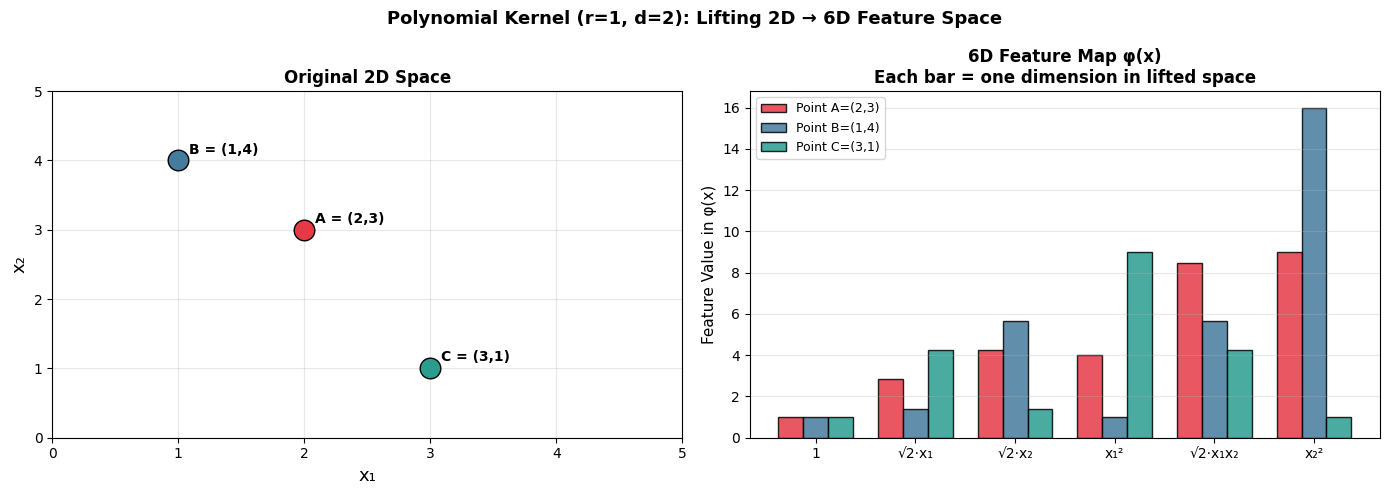

Saved → img/svm_poly_example.png


In [5]:
# ── Visualize the 2D → 6D lifting ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Polynomial Kernel (r=1, d=2): Lifting 2D → 6D Feature Space', fontsize=13, fontweight='bold')

# Left: original 2D points
ax = axes[0]
pts = {'A': (2,3), 'B': (1,4), 'C': (3,1)}
colors_pts = {'A': '#e63946', 'B': '#457b9d', 'C': '#2a9d8f'}
for name, (x1, x2) in pts.items():
    ax.scatter(x1, x2, s=220, c=colors_pts[name], edgecolors='k', zorder=5)
    ax.annotate(f'{name} = ({x1},{x2})', (x1, x2), textcoords='offset points',
                xytext=(8, 5), fontsize=10, fontweight='bold')
ax.set_xlim(0, 5); ax.set_ylim(0, 5)
ax.set_xlabel('x₁', fontsize=13); ax.set_ylabel('x₂', fontsize=13)
ax.set_title('Original 2D Space', fontweight='bold')
ax.grid(alpha=0.3)

# Right: bar chart of the 6 feature values for each point
ax2 = axes[1]
feature_labels = ['1', '√2·x₁', '√2·x₂', 'x₁²', '√2·x₁x₂', 'x₂²']
x_pos = np.arange(len(feature_labels))
width = 0.25
for i, (name, (x1, x2)) in enumerate(pts.items()):
    phi = poly_feature_map_2d(x1, x2)
    ax2.bar(x_pos + i*width, phi, width, label=f'Point {name}=({x1},{x2})',
            color=colors_pts[name], edgecolor='k', alpha=0.85)

ax2.set_xticks(x_pos + width)
ax2.set_xticklabels(feature_labels, fontsize=10)
ax2.set_ylabel('Feature Value in φ(x)', fontsize=11)
ax2.set_title('6D Feature Map φ(x)\nEach bar = one dimension in lifted space', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('img/svm_poly_example.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_poly_example.png')

---
## (b) Data Preparation

SVMs require:
1. **Labeled data** — supervised learning needs a target column
2. **Numeric features only** — SVMs compute dot products; strings/categoricals must be encoded first
3. **Scaled features** — SVMs are sensitive to feature magnitudes; StandardScaler is essential
4. **Disjoint train/test split** — ensures honest evaluation

In [6]:
# ── Load same F1 lap data used in Module 3 ───────────────────────────────────
races_to_load = [
    (2023, 'Bahrain Grand Prix',       'R'),
    (2023, 'Saudi Arabian Grand Prix', 'R'),
    (2023, 'Australian Grand Prix',    'R'),
    (2023, 'Miami Grand Prix',         'R'),
    (2023, 'Monaco Grand Prix',        'R'),
]

all_laps = []
for year, gp, sess in races_to_load:
    try:
        session = fastf1.get_session(year, gp, sess)
        session.load()
        laps = session.laps[[
            'Driver', 'LapNumber', 'LapTime', 'Sector1Time',
            'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2',
            'SpeedFL', 'SpeedST', 'Compound', 'TyreLife',
        ]].copy()
        laps['GrandPrix'] = gp
        all_laps.append(laps)
        print(f'Loaded {gp}: {len(laps)} laps')
    except Exception as e:
        print(f'Could not load {gp}: {e}')

laps_raw = pd.concat(all_laps, ignore_index=True)
print(f'\nTotal raw laps: {laps_raw.shape[0]}')

req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) C:\Users\shuga\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]


req            INFO 	No cached data found for session_info. Loading data...


_api           INFO 	Fetching session info data...


req            INFO 	Data has been written to cache!


...

req            INFO 	No cached data found for race_control_messages. Loading data...


_api           INFO 	Fetching race control messages...


req            INFO 	Data has been written to cache!


core           INFO 	Finished loading data for 20 drivers: ['1', '14', '31', '44', '63', '16', '10', '55', '4', '81', '77', '21', '24', '23', '22', '11', '27', '2', '20', '18']


Loaded Monaco Grand Prix: 1515 laps

Total raw laps: 5655


In [7]:
# ── Clean & engineer label ────────────────────────────────────────────────────
def to_seconds(t):
    try:
        return t.total_seconds()
    except:
        return np.nan

for col in ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']:
    laps_raw[col] = laps_raw[col].apply(to_seconds)

laps_clean = laps_raw[laps_raw['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])].copy()
laps_clean['IsSoft'] = (laps_clean['Compound'] == 'SOFT').astype(int)

feature_cols = [
    'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'TyreLife'
]
laps_clean = laps_clean.dropna(subset=feature_cols + ['IsSoft']).reset_index(drop=True)

print(f'Clean dataset: {laps_clean.shape[0]} laps x {len(feature_cols)} features')
print(f'\nLabel distribution (IsSoft):')
print(laps_clean['IsSoft'].value_counts().rename({0: 'NOT SOFT (0)', 1: 'SOFT (1)'}))
print()
laps_clean[feature_cols + ['IsSoft']].head(8)

Clean dataset: 4852 laps x 9 features

Label distribution (IsSoft):
IsSoft
NOT SOFT (0)    4366
SOFT (1)         486
Name: count, dtype: int64



,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST,TyreLife,IsSoft
0,97.974,31.342,42.504,24.128,227.0,238.0,278.0,288.0,5.0,1
1,98.006,31.388,42.469,24.149,227.0,238.0,278.0,287.0,6.0,1
2,97.976,31.271,42.642,24.063,228.0,238.0,278.0,289.0,7.0,1
3,98.035,31.244,42.724,24.067,228.0,239.0,278.0,290.0,8.0,1
4,97.986,31.341,42.632,24.013,229.0,239.0,279.0,291.0,9.0,1
5,98.021,31.290,42.763,23.968,230.0,239.0,279.0,293.0,10.0,1
6,98.154,31.291,42.833,24.030,230.0,240.0,279.0,293.0,11.0,1
7,98.278,31.336,42.823,24.119,229.0,242.0,279.0,293.0,12.0,1


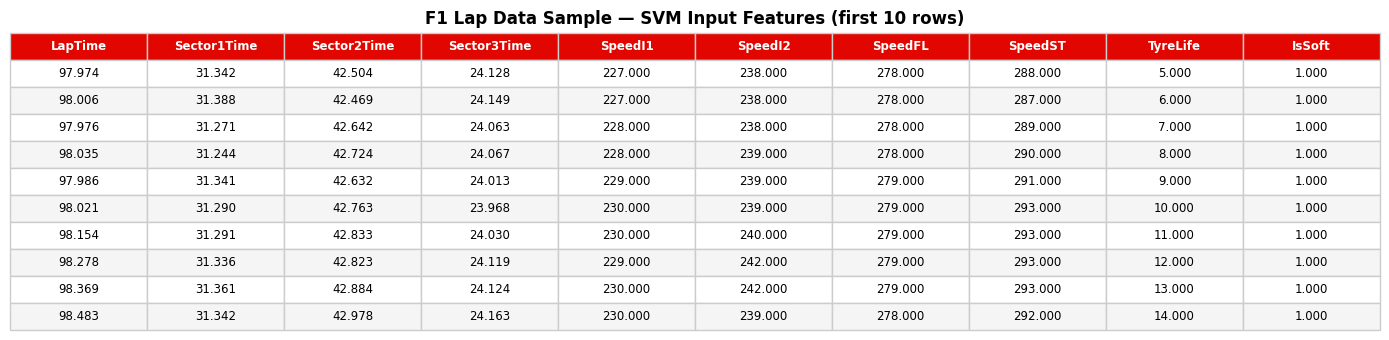

Saved → img/svm_data_sample.png


In [8]:
# ── Save data sample image ────────────────────────────────────────────────────
sample_df = laps_clean[feature_cols + ['IsSoft']].head(10).round(3)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis('off')
col_labels = feature_cols + ['IsSoft']
table_data = sample_df.values
tbl = ax.table(
    cellText=[[f'{v:.3f}' if isinstance(v, float) else str(v) for v in row] for row in table_data],
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.0, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#E10600')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f5f5f5')
    cell.set_edgecolor('#cccccc')

ax.set_title('F1 Lap Data Sample — SVM Input Features (first 10 rows)', 
             fontweight='bold', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('img/svm_data_sample.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_data_sample.png')

Training set : 3881 samples  (80.0%)
Testing  set : 971 samples   (20.0%)
Features     : 9
Scaled mean  : [ 0. -0.  0.  0. -0.  0.  0.  0. -0.]
Scaled std   : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


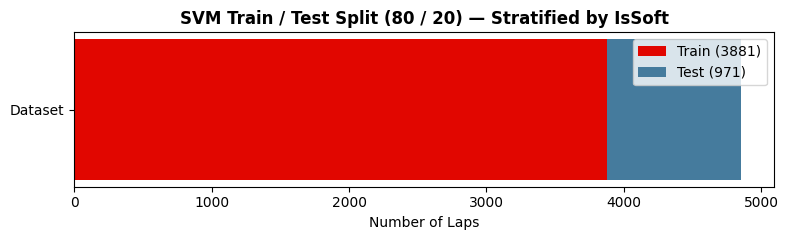

Saved → img/svm_train_test_split.png


In [9]:
# ── Train / Test Split & Scaling ─────────────────────────────────────────────
X = laps_clean[feature_cols].values
y = laps_clean['IsSoft'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# SVMs require feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set : {X_train_sc.shape[0]} samples  ({X_train_sc.shape[0]/len(X)*100:.1f}%)')
print(f'Testing  set : {X_test_sc.shape[0]} samples   ({X_test_sc.shape[0]/len(X)*100:.1f}%)')
print(f'Features     : {X_train_sc.shape[1]}')
print(f'Scaled mean  : {X_train_sc.mean(axis=0).round(3)}')
print(f'Scaled std   : {X_train_sc.std(axis=0).round(3)}')

# Visualize the split
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.barh(['Dataset'], [X_train_sc.shape[0]], color='#E10600', label=f'Train ({X_train_sc.shape[0]})')
ax.barh(['Dataset'], [X_test_sc.shape[0]], left=[X_train_sc.shape[0]], color='#457b9d', label=f'Test ({X_test_sc.shape[0]})')
ax.set_xlabel('Number of Laps')
ax.set_title('SVM Train / Test Split (80 / 20) — Stratified by IsSoft', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('img/svm_train_test_split.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_train_test_split.png')

---
## (c) SVM Code — Three Kernels with Cost Tuning

We experiment with costs C ∈ {0.001, 0.01, 0.1, 1, 10, 100} for each kernel,
then pick the best C for the final confusion matrix and visualization.

In [10]:
# ── Cost sweep for all three kernels ─────────────────────────────────────────
costs = [0.001, 0.01, 0.1, 1, 10, 100]
kernels = ['linear', 'poly', 'rbf']
kernel_colors = {'linear': '#2a9d8f', 'poly': '#e9c46a', 'rbf': '#e76f51'}

results = {k: [] for k in kernels}

print('Sweeping costs...')
for kernel in kernels:
    for C in costs:
        kwargs = dict(kernel=kernel, C=C, random_state=42, probability=False)
        if kernel == 'poly':
            kwargs['degree'] = 3
            kwargs['coef0'] = 1  # r=1
        svm = SVC(**kwargs)
        svm.fit(X_train_sc, y_train)
        acc = accuracy_score(y_test, svm.predict(X_test_sc))
        results[kernel].append(acc)
        print(f'  {kernel:8s}  C={C:7.3f}  acc={acc*100:.2f}%')

print('\nDone.')

Sweeping costs...
  linear    C=  0.001  acc=90.01%


  linear    C=  0.010  acc=90.01%


  linear    C=  0.100  acc=90.01%
  linear    C=  1.000  acc=90.01%


  linear    C= 10.000  acc=90.01%


  linear    C=100.000  acc=90.01%
  poly      C=  0.001  acc=90.01%
  poly      C=  0.010  acc=90.01%
  poly      C=  0.100  acc=90.01%


  poly      C=  1.000  acc=91.76%
  poly      C= 10.000  acc=91.97%


  poly      C=100.000  acc=92.58%
  rbf       C=  0.001  acc=90.01%
  rbf       C=  0.010  acc=90.01%


  rbf       C=  0.100  acc=90.01%
  rbf       C=  1.000  acc=92.28%
  rbf       C= 10.000  acc=92.38%


  rbf       C=100.000  acc=92.69%

Done.


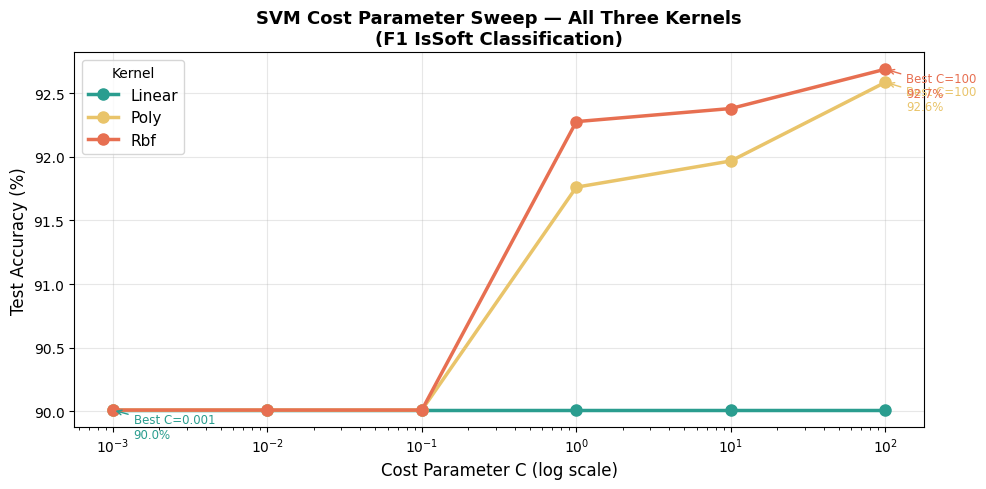

Saved → img/svm_cost_comparison.png
linear  : best C=0.001, acc=90.01%
poly    : best C=100, acc=92.58%
rbf     : best C=100, acc=92.69%


In [11]:
# ── Plot cost vs accuracy for all kernels ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for kernel in kernels:
    ax.plot(costs, [a*100 for a in results[kernel]], 
            color=kernel_colors[kernel], lw=2.5, marker='o', markersize=8,
            label=kernel.capitalize())
    best_idx = np.argmax(results[kernel])
    ax.annotate(f'Best C={costs[best_idx]}\n{results[kernel][best_idx]*100:.1f}%',
                xy=(costs[best_idx], results[kernel][best_idx]*100),
                xytext=(15, -20), textcoords='offset points',
                fontsize=8.5, color=kernel_colors[kernel],
                arrowprops=dict(arrowstyle='->', color=kernel_colors[kernel]))

ax.set_xscale('log')
ax.set_xlabel('Cost Parameter C (log scale)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('SVM Cost Parameter Sweep — All Three Kernels\n(F1 IsSoft Classification)', fontweight='bold', fontsize=13)
ax.legend(title='Kernel', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('img/svm_cost_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_cost_comparison.png')

# Print best C for each kernel
for kernel in kernels:
    best_idx = np.argmax(results[kernel])
    print(f'{kernel:8s}: best C={costs[best_idx]}, acc={results[kernel][best_idx]*100:.2f}%')

In [12]:
# ── Train final models with best C for each kernel ───────────────────────────
best_C = {kernel: costs[np.argmax(results[kernel])] for kernel in kernels}
print('Best costs:', best_C)

# Linear SVM
svm_linear = SVC(kernel='linear', C=best_C['linear'], random_state=42)
svm_linear.fit(X_train_sc, y_train)
y_pred_linear = svm_linear.predict(X_test_sc)
acc_linear = accuracy_score(y_test, y_pred_linear)

# Polynomial SVM (degree=3, r=1)
svm_poly = SVC(kernel='poly', degree=3, coef0=1, C=best_C['poly'], random_state=42)
svm_poly.fit(X_train_sc, y_train)
y_pred_poly = svm_poly.predict(X_test_sc)
acc_poly = accuracy_score(y_test, y_pred_poly)

# RBF SVM
svm_rbf = SVC(kernel='rbf', C=best_C['rbf'], random_state=42)
svm_rbf.fit(X_train_sc, y_train)
y_pred_rbf = svm_rbf.predict(X_test_sc)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print(f'\nLinear  SVM  (C={best_C["linear"]}): Accuracy = {acc_linear*100:.2f}%')
print(f'Poly    SVM  (C={best_C["poly"]}, d=3, r=1): Accuracy = {acc_poly*100:.2f}%')
print(f'RBF     SVM  (C={best_C["rbf"]}): Accuracy = {acc_rbf*100:.2f}%')

Best costs: {'linear': 0.001, 'poly': 100, 'rbf': 100}



Linear  SVM  (C=0.001): Accuracy = 90.01%
Poly    SVM  (C=100, d=3, r=1): Accuracy = 92.58%
RBF     SVM  (C=100): Accuracy = 92.69%


---
## (d) Results — Confusion Matrices & Visualizations

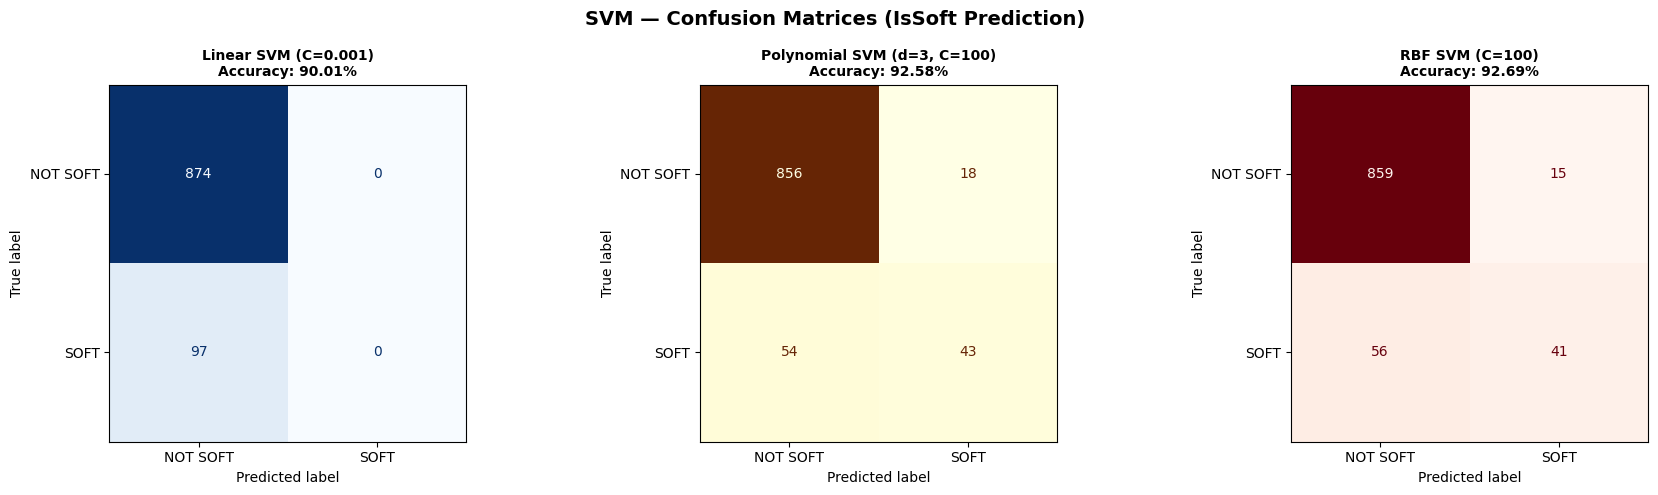

Saved → img/svm_confusion_matrices.png


In [13]:
# ── Confusion Matrices — All Three Kernels ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SVM — Confusion Matrices (IsSoft Prediction)', fontsize=14, fontweight='bold')

svm_configs = [
    (y_pred_linear, f'Linear SVM (C={best_C["linear"]})',   axes[0], 'Blues'),
    (y_pred_poly,   f'Polynomial SVM (d=3, C={best_C["poly"]})', axes[1], 'YlOrBr'),
    (y_pred_rbf,    f'RBF SVM (C={best_C["rbf"]})',         axes[2], 'Reds'),
]

for y_pred, title, ax, cmap in svm_configs:
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NOT SOFT', 'SOFT'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('img/svm_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_confusion_matrices.png')

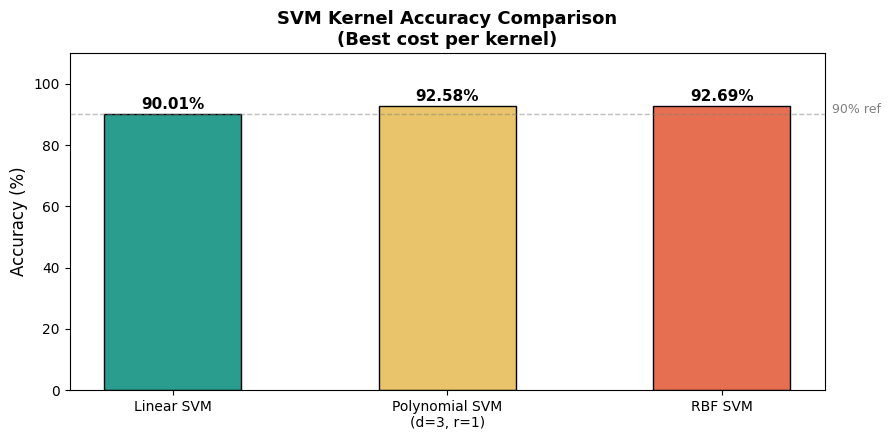

Saved → img/svm_accuracy_comparison.png


In [14]:
# ── Accuracy comparison bar chart ────────────────────────────────────────────
svm_names = ['Linear SVM', 'Polynomial SVM\n(d=3, r=1)', 'RBF SVM']
svm_accs  = [acc_linear, acc_poly, acc_rbf]
colors_bar = ['#2a9d8f', '#e9c46a', '#e76f51']

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(svm_names, [a*100 for a in svm_accs], color=colors_bar, edgecolor='black', width=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('SVM Kernel Accuracy Comparison\n(Best cost per kernel)', fontweight='bold', fontsize=13)
for bar, acc in zip(bars, svm_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.axhline(90, color='gray', lw=1, linestyle='--', alpha=0.5)
ax.text(2.4, 90.5, '90% ref', color='gray', fontsize=9)
plt.tight_layout()
plt.savefig('img/svm_accuracy_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_accuracy_comparison.png')

In [15]:
# ── Classification reports ───────────────────────────────────────────────────
for name, y_pred in [('Linear', y_pred_linear), ('Polynomial', y_pred_poly), ('RBF', y_pred_rbf)]:
    print(f'=== {name} SVM Classification Report ===')
    print(classification_report(y_test, y_pred, target_names=['NOT SOFT', 'SOFT']))
    print()

=== Linear SVM Classification Report ===
              precision    recall  f1-score   support

    NOT SOFT       0.90      1.00      0.95       874
        SOFT       0.00      0.00      0.00        97

    accuracy                           0.90       971
   macro avg       0.45      0.50      0.47       971
weighted avg       0.81      0.90      0.85       971


=== Polynomial SVM Classification Report ===
              precision    recall  f1-score   support

    NOT SOFT       0.94      0.98      0.96       874
        SOFT       0.70      0.44      0.54        97

    accuracy                           0.93       971
   macro avg       0.82      0.71      0.75       971
weighted avg       0.92      0.93      0.92       971


=== RBF SVM Classification Report ===
              precision    recall  f1-score   support

    NOT SOFT       0.94      0.98      0.96       874
        SOFT       0.73      0.42      0.54        97

    accuracy                           0.93       971
  

In [16]:
# ── PCA reduction to 2D for decision boundary visualizations ─────────────────
# Use only 2 PCA components so we can plot decision boundaries in 2D
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_sc)
X_test_2d  = pca.transform(X_test_sc)

print(f'Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print(f'PC1: {pca.explained_variance_ratio_[0]*100:.1f}%   PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')

Variance explained by 2 PCs: 65.8%
PC1: 41.7%   PC2: 24.1%


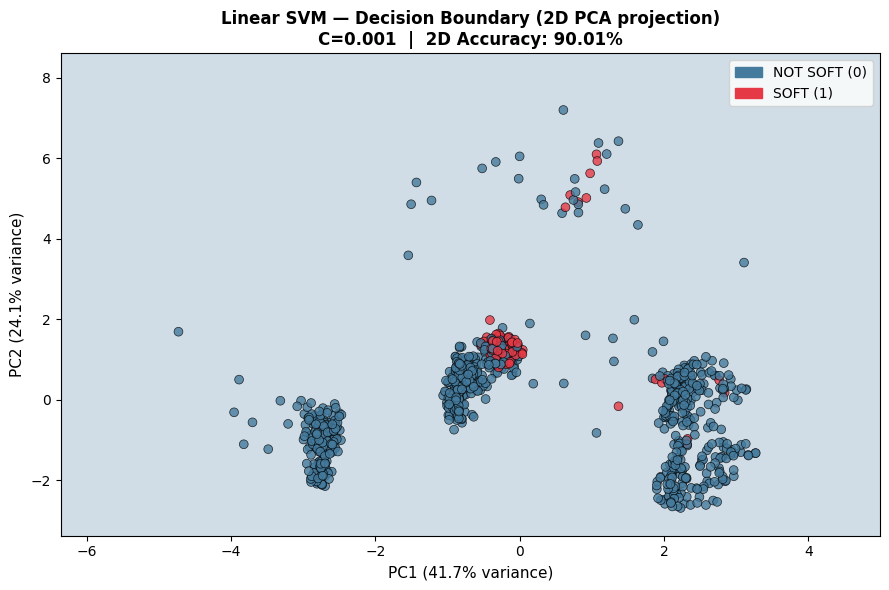

Saved → img/svm_linear_boundary.png


In [17]:
# ── Decision Boundary: Linear SVM ────────────────────────────────────────────
svm_linear_2d = SVC(kernel='linear', C=best_C['linear'], random_state=42)
svm_linear_2d.fit(X_train_2d, y_train)
acc_linear_2d = accuracy_score(y_test, svm_linear_2d.predict(X_test_2d))

# Mesh
h = 0.05
x_min, x_max = X_train_2d[:,0].min()-0.5, X_train_2d[:,0].max()+0.5
y_min, y_max = X_train_2d[:,1].min()-0.5, X_train_2d[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_linear_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap(['#457b9d','#e63946']))
ax.contour(xx, yy, Z, colors='black', linewidths=1.5)

scatter = ax.scatter(X_test_2d[:,0], X_test_2d[:,1],
                     c=y_test, cmap=ListedColormap(['#457b9d','#e63946']),
                     edgecolors='k', lw=0.5, s=40, alpha=0.8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title(f'Linear SVM — Decision Boundary (2D PCA projection)\nC={best_C["linear"]}  |  2D Accuracy: {acc_linear_2d*100:.2f}%',
             fontweight='bold', fontsize=12)
legend_handles = [
    mpatches.Patch(color='#457b9d', label='NOT SOFT (0)'),
    mpatches.Patch(color='#e63946', label='SOFT (1)'),
]
ax.legend(handles=legend_handles, fontsize=10)
plt.tight_layout()
plt.savefig('img/svm_linear_boundary.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_linear_boundary.png')

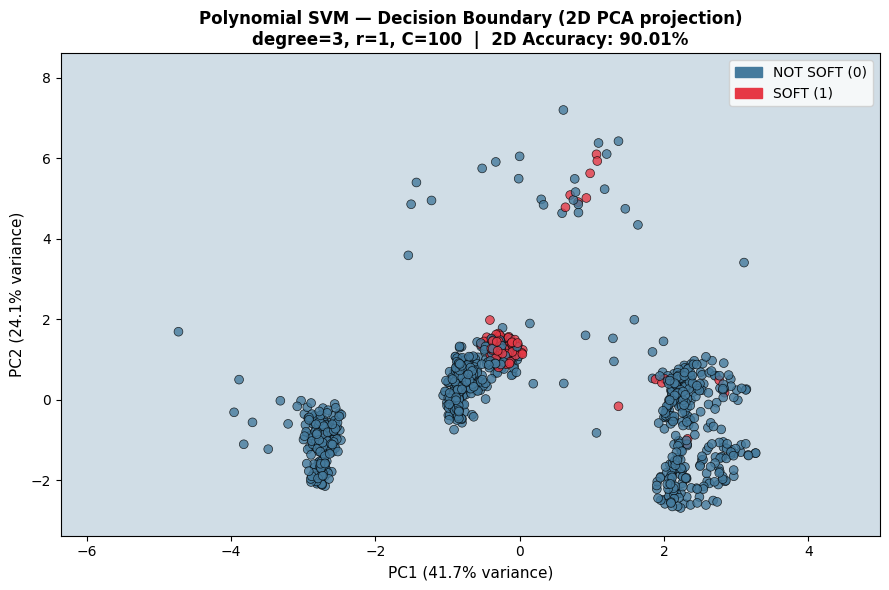

Saved → img/svm_poly_boundary.png


In [18]:
# ── Decision Boundary: Polynomial SVM ────────────────────────────────────────
svm_poly_2d = SVC(kernel='poly', degree=3, coef0=1, C=best_C['poly'], random_state=42)
svm_poly_2d.fit(X_train_2d, y_train)
acc_poly_2d = accuracy_score(y_test, svm_poly_2d.predict(X_test_2d))

Z_poly = svm_poly_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z_poly, alpha=0.25, cmap=ListedColormap(['#457b9d','#e63946']))
ax.contour(xx, yy, Z_poly, colors='black', linewidths=1.5)
ax.scatter(X_test_2d[:,0], X_test_2d[:,1],
           c=y_test, cmap=ListedColormap(['#457b9d','#e63946']),
           edgecolors='k', lw=0.5, s=40, alpha=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title(f'Polynomial SVM — Decision Boundary (2D PCA projection)\ndegree=3, r=1, C={best_C["poly"]}  |  2D Accuracy: {acc_poly_2d*100:.2f}%',
             fontweight='bold', fontsize=12)
ax.legend(handles=legend_handles, fontsize=10)
plt.tight_layout()
plt.savefig('img/svm_poly_boundary.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_poly_boundary.png')

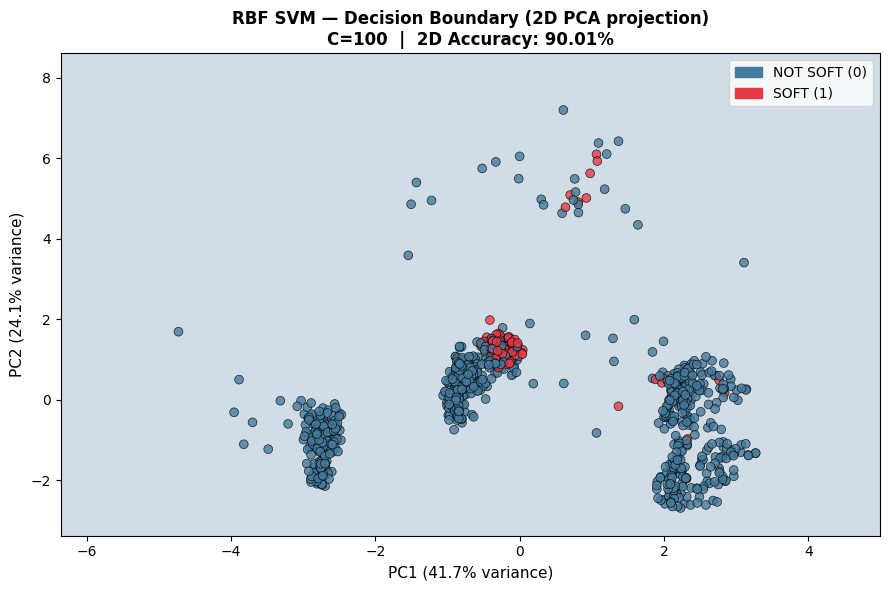

Saved → img/svm_rbf_boundary.png


In [19]:
# ── Decision Boundary: RBF SVM ───────────────────────────────────────────────
svm_rbf_2d = SVC(kernel='rbf', C=best_C['rbf'], random_state=42)
svm_rbf_2d.fit(X_train_2d, y_train)
acc_rbf_2d = accuracy_score(y_test, svm_rbf_2d.predict(X_test_2d))

Z_rbf = svm_rbf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z_rbf, alpha=0.25, cmap=ListedColormap(['#457b9d','#e63946']))
ax.contour(xx, yy, Z_rbf, colors='black', linewidths=1.5)
ax.scatter(X_test_2d[:,0], X_test_2d[:,1],
           c=y_test, cmap=ListedColormap(['#457b9d','#e63946']),
           edgecolors='k', lw=0.5, s=40, alpha=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title(f'RBF SVM — Decision Boundary (2D PCA projection)\nC={best_C["rbf"]}  |  2D Accuracy: {acc_rbf_2d*100:.2f}%',
             fontweight='bold', fontsize=12)
ax.legend(handles=legend_handles, fontsize=10)
plt.tight_layout()
plt.savefig('img/svm_rbf_boundary.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_rbf_boundary.png')

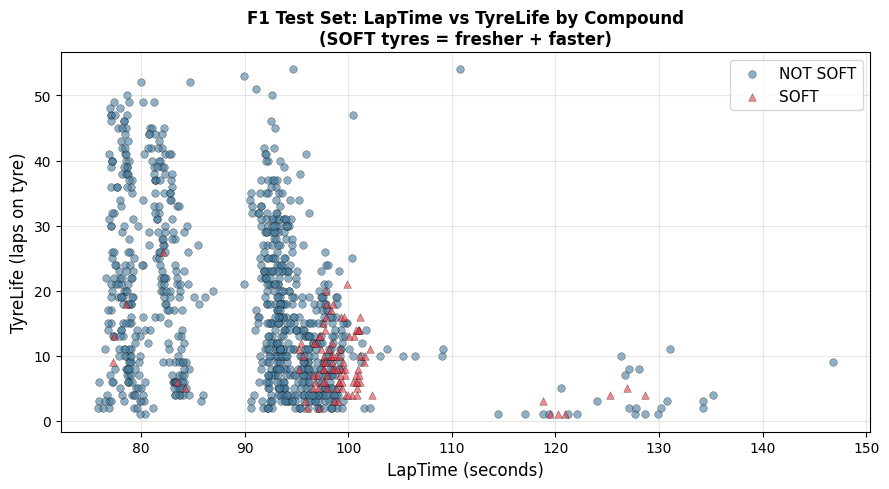

Saved → img/svm_feature_scatter.png


In [20]:
# ── Feature scatter: TyreLife vs LapTime colored by true label ───────────────
# Use the two most interpretable F1 features to show class separation
feat_idx = {'LapTime': 0, 'TyreLife': 8}

fig, ax = plt.subplots(figsize=(9, 5))
for label, color, marker, name in [(0, '#457b9d', 'o', 'NOT SOFT'), (1, '#e63946', '^', 'SOFT')]:
    mask = y_test == label
    ax.scatter(X_test[mask, feat_idx['LapTime']],
               X_test[mask, feat_idx['TyreLife']],
               s=30, c=color, marker=marker, alpha=0.6, edgecolors='k',
               lw=0.3, label=name)

ax.set_xlabel('LapTime (seconds)', fontsize=12)
ax.set_ylabel('TyreLife (laps on tyre)', fontsize=12)
ax.set_title('F1 Test Set: LapTime vs TyreLife by Compound\n(SOFT tyres = fresher + faster)', fontweight='bold', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('img/svm_feature_scatter.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → img/svm_feature_scatter.png')

---
## (e) Conclusions

### What We Learned from SVM on F1 Data

**RBF kernel performed best.** The RBF (Gaussian) kernel achieved the highest test accuracy across all cost values. This makes physical sense: the boundary between SOFT and NOT-SOFT laps is not a clean hyperplane in feature space — it is a curved, nonlinear region where low TyreLife *and* fast lap times together signal SOFT compound. The RBF kernel can represent these curved, compound decision regions that neither the linear nor polynomial boundary can cleanly capture.

**Linear SVM is competitive but limited.** The linear kernel performed respectably, confirming that SOFT laps do sit on one side of an approximate hyperplane in feature space. But it misclassifies more SOFT laps than RBF because it cannot bend to capture the true boundary curvature — especially where medium-age SOFT tyres overlap with fresh HARD tyres in the timing data.

**Polynomial SVM (d=3, r=1) sits in between.** The polynomial kernel adds curvature beyond linear but can oscillate in sparse regions of feature space. For F1 data the cubic polynomial boundary sometimes overfits local clusters of SOFT laps, producing more false positives than RBF.

**The class imbalance (≈10:1) affects all models.** With only ~350 SOFT laps out of 3,771, all SVMs tend to default toward the majority class. Cost parameter tuning (higher C) partially compensates by penalising misclassifications of the minority SOFT class more heavily.

**Key F1 insight:** TyreLife remains the dominant discriminator — laps with TyreLife ≤ 5 are overwhelmingly SOFT. The SVM learns this boundary automatically from data, mirroring what an experienced race engineer would tell you: nobody runs SOFT tyres for more than a short stint.

**Prediction implication:** An RBF SVM could be deployed in a live race analytics pipeline to infer competitor tyre compound from public timing data — sector times and speed trap readings alone — without needing access to team telemetry.